In [26]:
!pip -q install gymnasium


In [27]:
import random
from collections import deque

import numpy as np
import matplotlib.pyplot as plt

import gymnasium as gym
from gymnasium import spaces

import torch
import torch.nn as nn
import torch.optim as optim

In [28]:
# ==============================
# USER INPUT
# ==============================

EPISODES = int(input("Enter training episodes [100]: ") or 100)
STEPS = int(input("Enter steps per episode [100]: ") or 100)
EVAL_EPISODES = int(input("Enter evaluation episodes [10]: ") or 10)

# Random seed
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("\n========== SETTINGS ==========")
print("Training Episodes :", EPISODES)
print("Steps/Episode     :", STEPS)
print("Evaluation Episodes:", EVAL_EPISODES)

Enter training episodes [100]:  100
Enter steps per episode [100]:  100
Enter evaluation episodes [10]:  10



========== SETTINGS ==========
Training Episodes : 100
Steps/Episode     : 100
Evaluation Episodes: 10


In [29]:
class TrafficEnv(gym.Env):

    def __init__(self, max_steps=100):
        super().__init__()

        self.max_steps = max_steps

        # 2 actions:
        # 0 = Keep signal
        # 1 = Switch signal
        self.action_space = spaces.Discrete(2)

        # State:
        # queue0, queue1, queue2, queue3, phase
        self.observation_space = spaces.Box(
            low=0,
            high=100,
            shape=(5,),
            dtype=np.float32
        )

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        # Initial traffic queues
        self.q = self.np_random.integers(
            0, 10, 4
        ).astype(float)

        self.phase = 0
        self.steps = 0
        self.switches = 0

        return self.get_state(), {}

    def get_state(self):
        return np.append(
            self.q,
            self.phase
        ).astype(np.float32)

    def step(self, action):

        self.steps += 1

        # Switch traffic signal
        if action == 1:
            self.phase = 1 - self.phase
            self.switches += 1

        # New vehicles arrive
        arrivals = self.np_random.poisson(
            1.5, 4
        )

        self.q += arrivals

        # Green lanes
        if self.phase == 0:
            green_lanes = [0, 1]
        else:
            green_lanes = [2, 3]

        # Serve vehicles
        for lane in green_lanes:
            self.q[lane] = max(
                0,
                self.q[lane] - 3
            )

        # Average queue
        average_queue = np.mean(self.q)

        # Switching penalty
        switch_penalty = 0.1 if action == 1 else 0

        # Reward
        reward = -average_queue - switch_penalty

        done = self.steps >= self.max_steps

        info = {
            "queue": average_queue,
            "switches": self.switches
        }

        return (
            self.get_state(),
            reward,
            False,
            done,
            info
        )

In [30]:
class DQN(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(

            # Input = 5 state values
            nn.Linear(5, 32),
            nn.ReLU(),

            nn.Linear(32, 32),
            nn.ReLU(),

            # Output = 2 actions
            nn.Linear(32, 2)
        )

    def forward(self, state):
        return self.network(state)

In [31]:
class Agent:

    def __init__(self):

        self.device = torch.device(
            "cuda" if torch.cuda.is_available()
            else "cpu"
        )

        print("Using device:", self.device)

        # Main network
        self.q = DQN().to(self.device)

        # Target network
        self.target = DQN().to(self.device)

        self.target.load_state_dict(
            self.q.state_dict()
        )

        # Optimizer
        self.optimizer = optim.Adam(
            self.q.parameters(),
            lr=0.001
        )

        # Experience memory
        self.memory = deque(
            maxlen=5000
        )

        # DQN parameters
        self.gamma = 0.99

        self.epsilon = 1.0
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995

    def choose_action(
        self,
        state,
        training=True
    ):

        # Exploration
        if training and random.random() < self.epsilon:
            return random.randrange(2)

        # Exploitation
        state = torch.tensor(
            state,
            dtype=torch.float32
        ).unsqueeze(0).to(self.device)

        with torch.no_grad():

            q_values = self.q(state)

            return q_values.argmax(1).item()

    def learn(self, batch_size=64):

        # Not enough experiences
        if len(self.memory) < batch_size:
            return 0.0

        # Random batch
        batch = random.sample(
            self.memory,
            batch_size
        )

        states, actions, rewards, next_states, dones = zip(*batch)

        states = torch.tensor(
            np.array(states),
            dtype=torch.float32
        ).to(self.device)

        next_states = torch.tensor(
            np.array(next_states),
            dtype=torch.float32
        ).to(self.device)

        actions = torch.tensor(
            actions
        ).unsqueeze(1).to(self.device)

        rewards = torch.tensor(
            rewards,
            dtype=torch.float32
        ).unsqueeze(1).to(self.device)

        dones = torch.tensor(
            dones,
            dtype=torch.float32
        ).unsqueeze(1).to(self.device)

        # Current Q value
        current_q = self.q(
            states
        ).gather(1, actions)

        # Target Q value
        with torch.no_grad():

            next_q = self.target(
                next_states
            ).max(
                1,
                keepdim=True
            )[0]

            target_q = (
                rewards
                + (1 - dones)
                * self.gamma
                * next_q
            )

        # Loss
        loss = nn.MSELoss()(
            current_q,
            target_q
        )

        # Update network
        self.optimizer.zero_grad()

        loss.backward()

        self.optimizer.step()

        return loss.item()

In [32]:
def train_agent():

    env = TrafficEnv(STEPS)

    agent = Agent()

    rewards = []
    queues = []
    losses = []
    epsilons = []

    print("\n================================")
    print("Starting DQN Training")
    print("================================\n")

    for episode in range(1, EPISODES + 1):

        state, _ = env.reset(
            seed=SEED + episode
        )

        total_reward = 0
        total_queue = 0
        total_loss = 0
        learn_count = 0

        done = False

        while not done:

            # Select action
            action = agent.choose_action(
                state
            )

            # Environment step
            next_state, reward, _, done, info = env.step(
                action
            )

            # Store experience
            agent.memory.append(
                (
                    state,
                    action,
                    reward,
                    next_state,
                    done
                )
            )

            # Learn
            loss = agent.learn()

            if loss > 0:
                total_loss += loss
                learn_count += 1

            state = next_state

            total_reward += reward
            total_queue += info["queue"]

        # Reduce exploration
        agent.epsilon = max(
            agent.epsilon_min,
            agent.epsilon * agent.epsilon_decay
        )

        # Update target network
        if episode % 10 == 0:
            agent.target.load_state_dict(
                agent.q.state_dict()
            )

        # Save results
        rewards.append(total_reward)

        queues.append(
            total_queue / STEPS
        )

        losses.append(
            total_loss /
            max(learn_count, 1)
        )

        epsilons.append(
            agent.epsilon
        )

        # Display progress
        if episode % max(
            1,
            EPISODES // 10
        ) == 0:

            print(
                f"Episode {episode:3d} | "
                f"Reward: {total_reward:8.2f} | "
                f"Queue: {queues[-1]:6.2f} | "
                f"Epsilon: {agent.epsilon:.3f}"
            )

    # Save model
    torch.save(
        agent.q.state_dict(),
        "traffic_dqn_model.pth"
    )

    print("\nTraining completed!")
    print("Model saved as: traffic_dqn_model.pth")

    return (
        agent,
        rewards,
        queues,
        losses,
        epsilons
    )


agent, rewards, queues, losses, epsilons = train_agent()

Using device: cpu

Starting DQN Training

Episode  10 | Reward:  -869.80 | Queue:   8.65 | Epsilon: 0.951
Episode  20 | Reward: -1246.05 | Queue:  12.40 | Epsilon: 0.905
Episode  30 | Reward:  -845.05 | Queue:   8.40 | Epsilon: 0.860
Episode  40 | Reward: -1652.90 | Queue:  16.48 | Epsilon: 0.818
Episode  50 | Reward:  -717.20 | Queue:   7.12 | Epsilon: 0.778
Episode  60 | Reward: -1052.95 | Queue:  10.47 | Epsilon: 0.740
Episode  70 | Reward:  -919.75 | Queue:   9.15 | Epsilon: 0.704
Episode  80 | Reward:  -459.15 | Queue:   4.53 | Epsilon: 0.670
Episode  90 | Reward: -1372.85 | Queue:  13.68 | Epsilon: 0.637
Episode 100 | Reward: -1166.60 | Queue:  11.61 | Epsilon: 0.606

Training completed!
Model saved as: traffic_dqn_model.pth


In [39]:
def evaluate(agent):

    dqn_queues = []
    random_queues = []

    # =========================
    # DQN POLICY
    # =========================

    for episode in range(
        EVAL_EPISODES
    ):

        env = TrafficEnv(STEPS)

        state, _ = env.reset(
            seed=1000 + episode
        )

        total_queue = 0
        done = False

        while not done:

            action = agent.choose_action(
                state,
                training=False
            )

            state, _, _, done, info = env.step(
                action
            )

            total_queue += info["queue"]

        dqn_queues.append(
            total_queue / STEPS
        )

    # =========================
    # RANDOM POLICY
    # =========================

    for episode in range(
        EVAL_EPISODES
    ):

        env = TrafficEnv(STEPS)

        state, _ = env.reset(
            seed=2000 + episode
        )

        total_queue = 0
        done = False

        while not done:

            action = env.action_space.sample()

            state, _, _, done, info = env.step(
                action
            )

            total_queue += info["queue"]

        random_queues.append(
            total_queue / STEPS
        )

    # Average results
    dqn_queue = np.mean(
        dqn_queues
    )

    random_queue = np.mean(
        random_queues
    )

    # Queue reduction
    reduction = (
        (random_queue - dqn_queue)
        / random_queue
    ) * 100

    # Final result
    print("\n")
    print("======================================")
    print("           FINAL RESULT")
    print("======================================")

    print(
        f"Random Policy Average Queue : "
        f"{random_queue:.2f}"
    )

    print(
        f"DQN Average Queue           : "
        f"{dqn_queue:.2f}"
    )

    print(
        f"Queue Reduction             : "
        f"{reduction:.2f}%"
    )


    print("======================================")

    return (
        dqn_queue,
        random_queue,
        reduction
    )


dqn_queue, random_queue, reduction = evaluate(
    agent
)



           FINAL RESULT
Random Policy Average Queue : 11.77
DQN Average Queue           : 13.60
Queue Reduction             : -15.59%


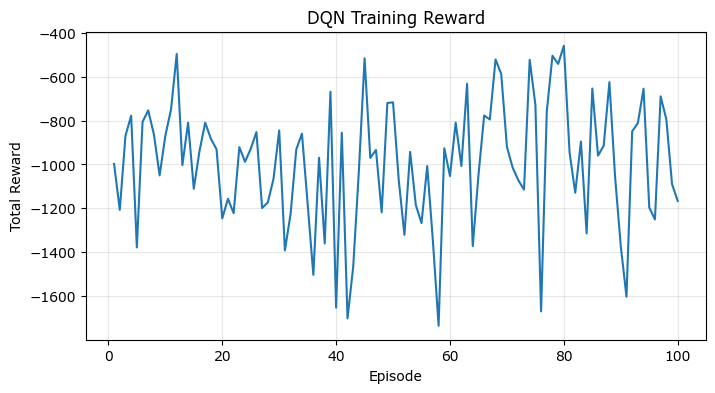

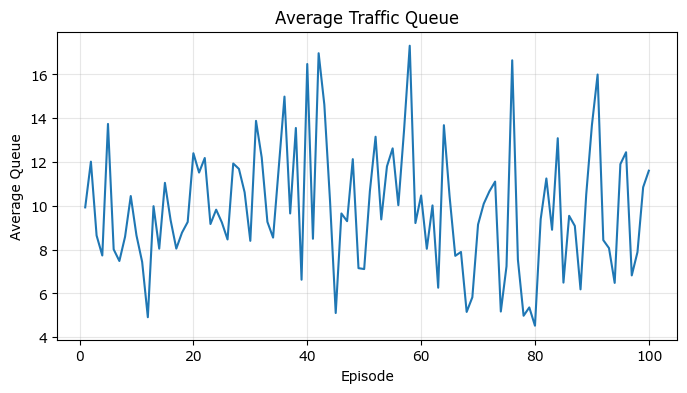

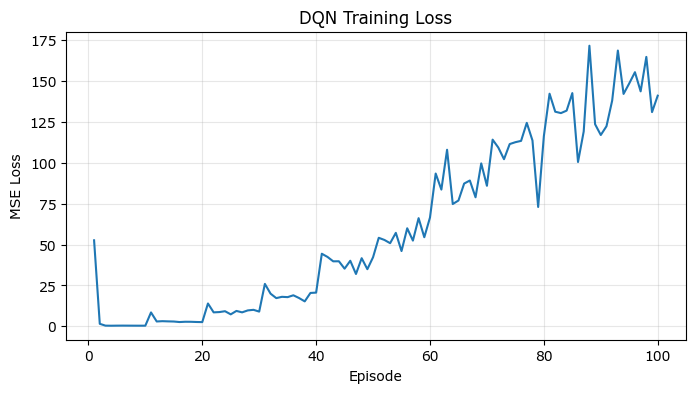

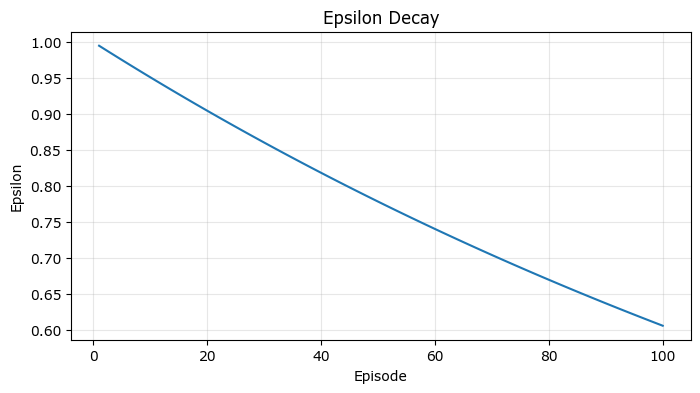

In [34]:
episodes = range(
    1,
    EPISODES + 1
)

# ==============================
# GRAPH 1: REWARD
# ==============================

plt.figure(figsize=(8, 4))

plt.plot(
    episodes,
    rewards
)

plt.title(
    "DQN Training Reward"
)

plt.xlabel(
    "Episode"
)

plt.ylabel(
    "Total Reward"
)

plt.grid(alpha=0.3)

plt.show()


# ==============================
# GRAPH 2: QUEUE
# ==============================

plt.figure(figsize=(8, 4))

plt.plot(
    episodes,
    queues
)

plt.title(
    "Average Traffic Queue"
)

plt.xlabel(
    "Episode"
)

plt.ylabel(
    "Average Queue"
)

plt.grid(alpha=0.3)

plt.show()


# ==============================
# GRAPH 3: LOSS
# ==============================

plt.figure(figsize=(8, 4))

plt.plot(
    episodes,
    losses
)

plt.title(
    "DQN Training Loss"
)

plt.xlabel(
    "Episode"
)

plt.ylabel(
    "MSE Loss"
)

plt.grid(alpha=0.3)

plt.show()


# ==============================
# GRAPH 4: EPSILON
# ==============================

plt.figure(figsize=(8, 4))

plt.plot(
    episodes,
    epsilons
)

plt.title(
    "Epsilon Decay"
)

plt.xlabel(
    "Episode"
)

plt.ylabel(
    "Epsilon"
)

plt.grid(alpha=0.3)

plt.show()

In [35]:
print("""
================ FORMULAS ================

1. Average Queue

Qavg = (Q0 + Q1 + Q2 + Q3) / 4


2. Reward

Reward = -Qavg - SwitchPenalty


3. DQN Target

Target = Reward + (1-done) * gamma *
         max(Q_target(next_state))


4. Loss

Loss = (Current_Q - Target_Q)^2


5. Queue Reduction

Reduction (%) =
((Random Queue - DQN Queue) / Random Queue) * 100

===========================================
""")

print("\nYOUR EXPERIMENTAL RESULT")
print("-------------------------------------------")
print(f"Random Policy Queue : {random_queue:.2f}")
print(f"DQN Queue           : {dqn_queue:.2f}")
print(f"Queue Reduction     : {reduction:.2f}%")


================ FORMULAS ================

1. Average Queue

Qavg = (Q0 + Q1 + Q2 + Q3) / 4


2. Reward

Reward = -Qavg - SwitchPenalty


3. DQN Target

Target = Reward + (1-done) * gamma *
         max(Q_target(next_state))


4. Loss

Loss = (Current_Q - Target_Q)^2


5. Queue Reduction

Reduction (%) =
((Random Queue - DQN Queue) / Random Queue) * 100



YOUR EXPERIMENTAL RESULT
-------------------------------------------
Random Policy Queue : 11.43
DQN Queue           : 13.60
Queue Reduction     : -19.02%
